## Imports

In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import LinearNDInterpolator

## Open all files

In [25]:
directory = 'processed_data/endurance.csv'
endurance_df = pd.read_csv(directory)

## Attempting to calculate controller efficiency ($\eta_{c}$)

### Available Variables:
- $I_{motor}$

- $V_{controller}$

- $V_{tractive}$

- $V_{battery}$

- $I_{battery}$

- $\omega_m$

- $\tau_m$

Using these variables, we can find the efficiency of the motor controller at every instant through the equation: $$\frac{\omega_m \times \tau_m}{I_{battery} \times V_{controller}} = \eta_c \times \eta_m = \eta_{dt}$$ This can be cross-referenced via: $$\frac{I_{motor} \times V_{controller}}{I_{battery} \times V_{controller}} = \eta_c \times \eta_m= \eta_{dt}$$ **Note: Motor current is not in Amps and must be converted before cross-referencing.**

Motor RPM is converted to rad/s through: $$\frac{RPM \times 2\pi}{60}$$ The code below performs the functions outlined above.

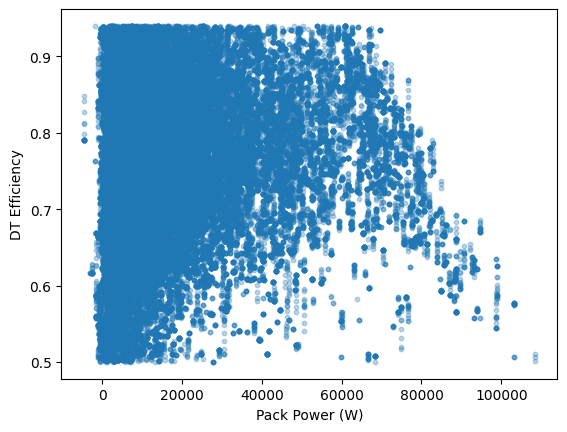

In [26]:
# calculate mechanical motor power
endurance_df['motor power (w)'] = endurance_df['real torque']*(endurance_df['motor rpm']*((2*np.pi)/60))

# calculate efficiency based on mechanical power
endurance_df['dt efficiency'] = endurance_df['motor power (w)']/endurance_df['pack power']

# drop the second half of the endurance_df as temperatures got too high, might impact efficiency
endurance_df = endurance_df.iloc[:len(endurance_df)//2]

# drop cases below 50% and above 94% (physics limited impossibilities)
endurance_df['dt efficiency'] = endurance_df['dt efficiency'].abs()
endurance_df = endurance_df[(endurance_df['dt efficiency'] >= 0.5) & (endurance_df['dt efficiency'] <= 0.94)]

# plot data
plt.scatter(endurance_df['pack power'], endurance_df['dt efficiency'], s=10, alpha=0.3)
plt.xlabel('Pack Power (W)')
plt.ylabel('DT Efficiency')
plt.show()

### The data is extremely noisy. As such, we will apply a regression model to try and extract meaning. I used LOESS (locally estimated scatterplot smoothing) to accomplish this as it is particularly resilient to noise.

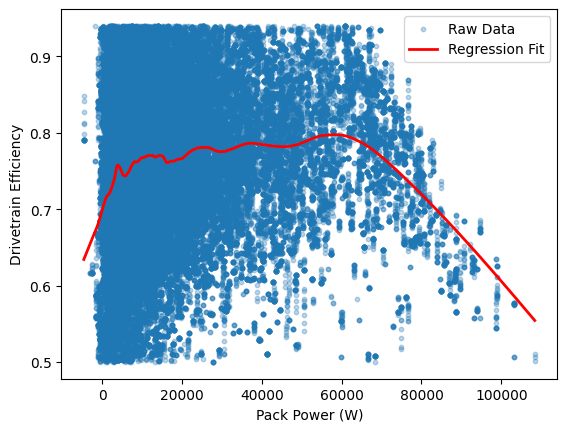

In [27]:
from statsmodels.nonparametric.smoothers_lowess import lowess

x = endurance_df['pack power']
y = endurance_df['dt efficiency']
reg_fit = lowess(y, x, frac=0.1)

plt.scatter(x, y, s=10, alpha=0.3, label='Raw Data')
plt.plot(reg_fit[:, 0], reg_fit[:, 1], color='red', linewidth=2, label='Regression Fit')
plt.legend()
plt.xlabel('Pack Power (W)')
plt.ylabel('Drivetrain Efficiency')
plt.show()


### Now, we will drop power greater than 60000W and less than 2500W as the data is sparse and seemingly nonrepresentative. Then, we will take the mean of the regression for a rough estimate of DT efficiency.

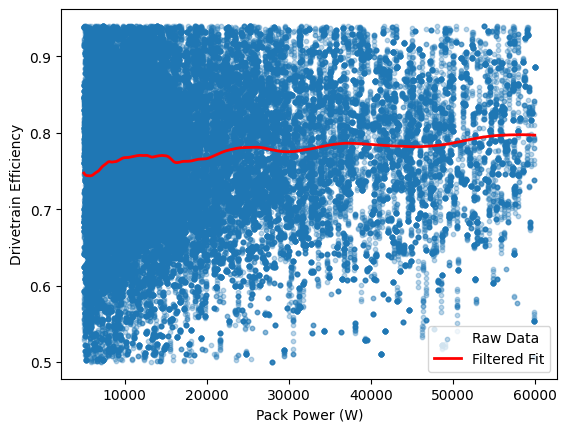

Average DT efficiency: 76.84%


In [28]:
# create endurance_df with the regression line
reg_endurance_df = pd.DataFrame(reg_fit, columns=['pack power', 'fitted efficiency'])

# filter down based on the above scheme
endurance_df = endurance_df[(endurance_df['pack power'] <= 60000) & (endurance_df['pack power'] >= 5000)]
reg_endurance_df_filtered = reg_endurance_df[(reg_endurance_df['pack power'] <= 60000) & (reg_endurance_df['pack power'] >= 5000)]

# calculate mean of the fit
mean_eta = reg_endurance_df_filtered['fitted efficiency'].mean()

# plot filtered data and regression fit
plt.scatter(endurance_df['pack power'], endurance_df['dt efficiency'], s=10, alpha=0.3, label='Raw Data')
plt.plot(reg_endurance_df_filtered['pack power'], reg_endurance_df_filtered['fitted efficiency'], color='red', linewidth=2, label='Filtered Fit')
plt.legend()
plt.xlabel('Pack Power (W)')
plt.ylabel('Drivetrain Efficiency')
plt.show()

# display dt efficiency
print(f'Average DT efficiency: {(mean_eta*100):.2f}%')


### Based on the logic earlier outlined, we are able to find motor efficiency at every instant via RPM and torque. I previously created a 3D lookup table to do this. Dividing each $\eta$ by this value and reapplying a regression model should yield $\eta_c$.

In [29]:
eff_map = pd.read_csv('Filtered_Efficiency_Map.csv')

# interpolator
interp_func = LinearNDInterpolator(
    points=eff_map[['RPM', 'Torque']].values,
    values=eff_map['eta'].values,
)

# interpolate efficiency at all points
points = np.column_stack((endurance_df['motor rpm'], endurance_df['real torque']))
endurance_df['motor efficiency'] = interp_func(points)

# divide out motor efficiency
endurance_df['controller efficiency'] = endurance_df['dt efficiency']/endurance_df['motor efficiency']

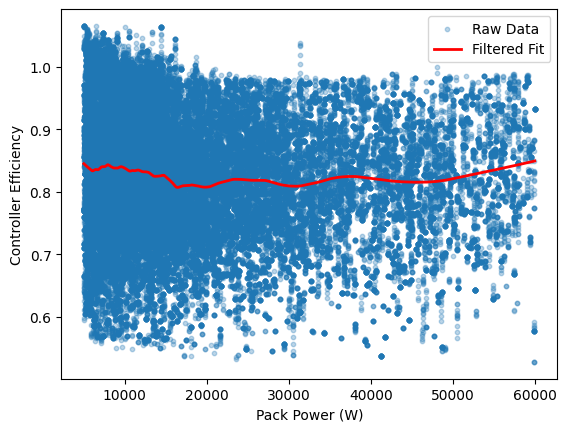

Average Controller Efficiency: 82.63%


In [30]:
x = endurance_df['pack power']
y = endurance_df['controller efficiency']
reg_fit = lowess(y, x, frac=0.1)

reg_endurance_df = pd.DataFrame(reg_fit, columns=['pack power', 'fitted efficiency'])
endurance_df_filtered = endurance_df[(endurance_df['pack power'] <= 60000) & (endurance_df['pack power'] >= 5000)]
reg_endurance_df_filtered = reg_endurance_df[(reg_endurance_df['pack power'] <= 60000) & (reg_endurance_df['pack power'] >= 5000)]
mean_eta = reg_endurance_df_filtered['fitted efficiency'].mean()

# plot
plt.scatter(endurance_df_filtered['pack power'], endurance_df_filtered['controller efficiency'], s=10, alpha=0.3, label='Raw Data')
plt.plot(reg_endurance_df_filtered['pack power'], reg_endurance_df_filtered['fitted efficiency'], color='red', linewidth=2, label='Filtered Fit')
plt.legend()
plt.xlabel('Pack Power (W)')
plt.ylabel('Controller Efficiency')
plt.show()

print(f'Average Controller Efficiency: {(mean_eta * 100):.2f}%')

### A final controller efficiency of ~83% suggests a significant issue is, such as:
- Data collection error
- Methodological errors
- Motor damage causing it to perform below curve
- Controller damage causing it to perform below 92% expected efficiency

**Further, if this value has any semblance of truth to it, it suggests a tractive cooling system with increased capacity is required.**
